In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
data = {
    'Movie Name': [
        'The Dark Horizon', 'Laughter Therapy', 'Cosmic Voyage', 'Shadows in the Woods',
        'Love & Latte', 'The Last Kingdom', 'Cyberpunk 2099', 'Laugh Out Loud',
        'Enchanted Forest', 'Deep Ocean', 'Rom-Com Fusion', 'The Chrono Thief',
        'Spies Next Door', 'Haunted Manor', 'Heartstrings'
    ],
    'Rating': [8.8, 6.2, 7.9, 5.4, 6.8, 8.5, 7.2, 6.5, 7.0, 8.1, 5.9, 9.1, 6.7, 4.8, 7.4],
    'Genre': [
        'Action', 'Comedy', 'Sci-Fi', 'Horror', 'Romance', 
        'Action', 'Sci-Fi', 'Comedy', 'Fantasy', 'Documentary', 
        'Romance', 'Sci-Fi', 'Action', 'Horror', 'Romance'
    ],
    'Revenue': [450, 120, 310, 45, 80, 600, 210, 95, 150, 40, 65, 850, 180, 25, 55] # in Millions
}
df = pd.DataFrame(data)

# highest rated movie
highest_rated_movie = df.sort_values(by = "Rating", ascending=False)
print("Highest Rated Movies (TOP 5): \n")
print(highest_rated_movie[["Movie Name", "Rating"]].head(5))

# most profitable movie (genre with highest revenue)
most_profitable_movie = df.groupby("Genre")["Revenue"].sum().idxmax()
print("\nMost Profitable Genre (By Revenue):")
print(most_profitable_movie)


Highest Rated Movies (TOP 5): 

          Movie Name  Rating
11  The Chrono Thief     9.1
0   The Dark Horizon     8.8
5   The Last Kingdom     8.5
9         Deep Ocean     8.1
2      Cosmic Voyage     7.9

Most Profitable Genre (By Revenue):
Sci-Fi


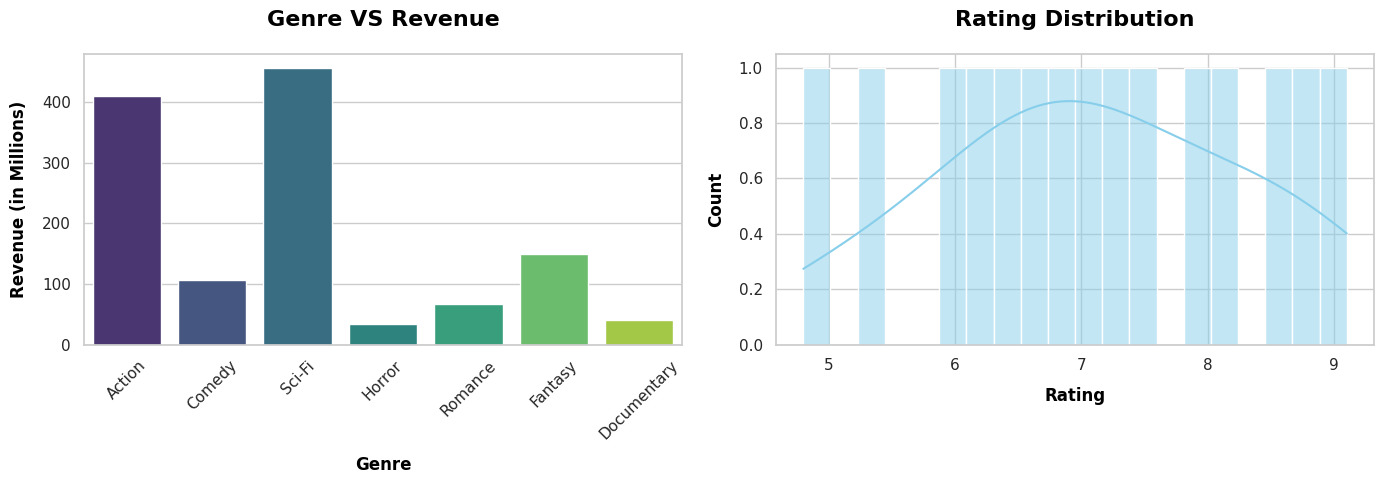

In [8]:
sns.set_theme(style = "whitegrid")
fig , axes = plt.subplots(1,2, figsize = (14,5))

# bar plot for genre vs revenue
sns.barplot(x = "Genre", y = "Revenue", data= df, ax = axes[0], palette = "viridis", hue = "Genre", errorbar=None)
axes[0].set_title("Genre VS Revenue", fontsize = 16, fontweight = "bold", pad = 20, color = "#000000")
axes[0].set_xlabel("Genre", fontsize = 12, fontweight = "bold", labelpad = 10, color = "#000000")
axes[0].set_ylabel("Revenue (in Millions)", fontsize = 12, fontweight = "bold", labelpad = 10, color = "#000000")
axes[0].tick_params(axis='x', rotation=45)

# histogram for rating distribution
sns.histplot(x = "Rating", data = df, ax = axes[1], bins = 20, kde = True, color = "skyblue")
axes[1].set_title("Rating Distribution", fontsize = 16, fontweight = "bold", pad = 20, color = "#000000")
axes[1].set_xlabel("Rating", fontsize = 12, fontweight = "bold", labelpad = 10, color = "#000000")
axes[1].set_ylabel("Count", fontsize = 12, fontweight = "bold", labelpad = 10, color = "#000000")

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


Correlation between Rating and Revenue: 0.76


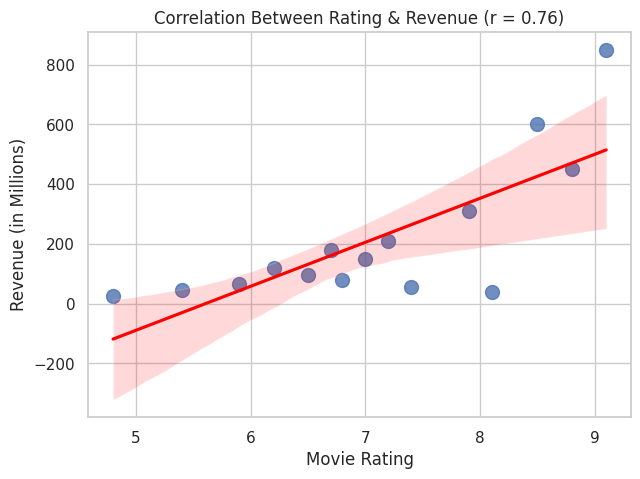

In [11]:
# Calculate correlation coefficient
correlation = df['Rating'].corr(df['Revenue'])
print(f"\nCorrelation between Rating and Revenue: {correlation:.2f}")

# Plotting the scatter plot
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='Rating', y='Revenue', scatter_kws={'s':100}, line_kws={'color':'red'})
plt.title(f'Correlation Between Rating & Revenue (r = {correlation:.2f})')
plt.xlabel('Movie Rating')
plt.ylabel('Revenue (in Millions)')
plt.show()